In [2]:
import numpy as np
import cvxpy as cp
from openqkd.solvers.fw2step import fw2step_solver

kraus_id = [np.eye(2)]
key_dim  = 2

# Pauli X como observável de restrição
X_pauli = np.array([[0., 1.], [1., 0.]])

# Teste 1: sem restrição de canal → mínimo = 0 (correto!)
def constraints_livre(rho_var):
    return [rho_var >> 0, cp.real(cp.trace(rho_var)) == 1]

plus = np.array([1., 1.]) / np.sqrt(2)
rho0 = np.outer(plus, plus)

r1 = fw2step_solver(rho0, kraus_id, constraints_livre, key_dim, verbose=False)
print(f"Teste 1 (sem restrição de canal)")
print(f"  Key rate : {r1['key_rate']:.6f} bits/round")
print(f"  Esperado : 0.000000  ← mínimo sobre todos os estados de 1 qubit\n")

# Teste 2: <X> = 1 força rho = |+><+| → key rate = 1 bit (correto!)
def constraints_ideal(rho_var):
    return [
        rho_var >> 0,
        cp.real(cp.trace(rho_var)) == 1,
        cp.real(cp.trace(X_pauli @ rho_var)) == 1.0   # <X> = 1 → rho = |+><+|
    ]

r2 = fw2step_solver(rho0, kraus_id, constraints_ideal, key_dim, verbose=True)
print(f"\nTeste 2 (<X> = 1, canal ideal)")
print(f"  Key rate : {r2['key_rate']:.6f} bits/round")
print(f"  Esperado : ~1.000000  ← log(2) = 1 bit")

# Teste 3: <X> = 0.8 → estado parcialmente coerente, resultado entre 0 e 1
def constraints_parcial(rho_var):
    return [
        rho_var >> 0,
        cp.real(cp.trace(rho_var)) == 1,
        cp.real(cp.trace(X_pauli @ rho_var)) == 0.8
    ]

r3 = fw2step_solver(rho0, kraus_id, constraints_parcial, key_dim, verbose=False)
print(f"\nTeste 3 (<X> = 0.8, canal com ruído)")
print(f"  Key rate : {r3['key_rate']:.6f} bits/round")
print(f"  Esperado : valor entre 0 e 1")


Teste 1 (sem restrição de canal)
  Key rate : 0.000000 bits/round
  Esperado : 0.000000  ← mínimo sobre todos os estados de 1 qubit

── Frank-Wolfe loop ──
  iter   1 | f(rho)=1.00000000 | FW gap=2.74e-08
  iter   2 | f(rho)=0.99999998 | FW gap=-2.11e-08
  Convergiu em 2 iterações.
── Dual certificate ──
  (modo simplificado)

  Upper bound : 0.99999998 bits/round
  Lower bound : 0.99999996 bits/round
  Epsilon     : 2.19e-08
  Leak EC     : 0.00000000 bits/round
  Key rate    : 0.99999996 bits/round

Teste 2 (<X> = 1, canal ideal)
  Key rate : 1.000000 bits/round
  Esperado : ~1.000000  ← log(2) = 1 bit

Teste 3 (<X> = 0.8, canal com ruído)
  Key rate : 0.531004 bits/round
  Esperado : valor entre 0 e 1


── Frank-Wolfe loop ──
  iter   1 | f(rho)=0.47232899 | FW gap=1.91e-02
  iter   2 | f(rho)=0.45960343 | FW gap=-1.90e-09
  Convergiu em 2 iterações.
── Dual certificate ──
  (modo rigoroso: Winick et al. Teorema 1/2/3)

  Upper bound : 0.45960343 bits/round
  Lower bound : 0.44622223 bits/round
  Epsilon     : 1.00e-04
  Leak EC     : 0.04039657 bits/round
  Key rate    : 0.40582567 bits/round

── Resultado ──────────────────────────────
  QBER      : 0.0100
  Leak EC   : 0.040397 bits/round
  Key rate  : 0.405826 bits/round


C:\Users\Mario\Documents\OpenQKD\openqkd_python\openqkd\solvers\fw2step.py:257: ComplexWarning: Casting complex values to real discards the imaginary part
  tr_term = float(np.trace(rho_star.T @ grad))
C:\Users\Mario\Documents\OpenQKD\openqkd_python\openqkd\solvers\fw2step.py:257: ComplexWarning: Casting complex values to real discards the imaginary part
  tr_term = float(np.trace(rho_star.T @ grad))


  e=0.000 → r=0.486525 bits/round
  e=0.008 → r=0.420119 bits/round
  e=0.016 → r=0.369549 bits/round
  e=0.024 → r=0.325019 bits/round
  e=0.032 → r=0.284446 bits/round
  e=0.039 → r=0.246839 bits/round
  e=0.047 → r=0.211616 bits/round
  e=0.055 → r=0.178393 bits/round
  e=0.063 → r=0.146896 bits/round
  e=0.071 → r=0.116921 bits/round
  e=0.079 → r=0.088310 bits/round
  e=0.087 → r=0.060937 bits/round
  e=0.095 → r=0.034699 bits/round
  e=0.103 → r=0.009510 bits/round
  e=0.111 → r=0.000000 bits/round
  e=0.118 → r=0.000000 bits/round
  e=0.126 → r=0.000000 bits/round
  e=0.134 → r=0.000000 bits/round
  e=0.142 → r=0.000000 bits/round
  e=0.150 → r=0.000000 bits/round


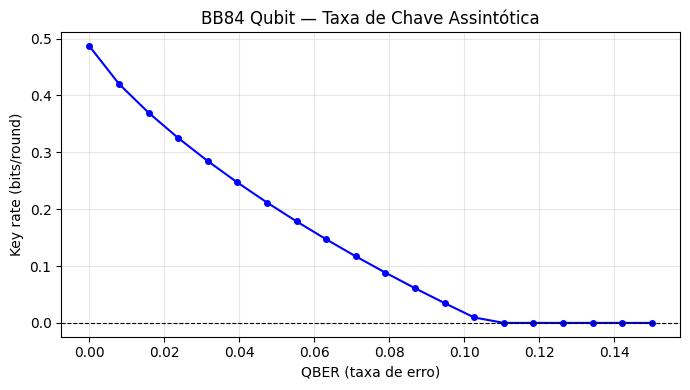

✅ Fase 4 concluída!


In [1]:
import sys
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

from openqkd.presets.bb84_preset import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration

# ── Teste único: QBER = 1% ────────────────────────────────────────────────────
qkd_input = BasicBB84Alice2DPreset(error_rate=0.01)
qkd_input.options["verbose"] = True

results = MainIteration(qkd_input)
print(f"\n── Resultado ──────────────────────────────")
print(f"  QBER      : {results['qber_Z']:.4f}")
print(f"  Leak EC   : {results['leak_ec']:.6f} bits/round")
print(f"  Key rate  : {results['key_rate']:.6f} bits/round")

# ── Varredura de QBER (equivalente ao QKDPlot do MATLAB) ──────────────────────
import numpy as np
import matplotlib.pyplot as plt

error_rates = np.linspace(0, 0.15, 20)
key_rates   = []

for e in error_rates:
    qkd = BasicBB84Alice2DPreset(error_rate=e)
    r   = MainIteration(qkd)
    key_rates.append(max(0.0, r["key_rate"]))
    print(f"  e={e:.3f} → r={key_rates[-1]:.6f} bits/round")

plt.figure(figsize=(7, 4))
plt.plot(error_rates, key_rates, 'b-o', markersize=4)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel("QBER (taxa de erro)")
plt.ylabel("Key rate (bits/round)")
plt.title("BB84 Qubit — Taxa de Chave Assintótica")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bb84_keyrate.png", dpi=150)
plt.show()
print("✅ Fase 4 concluída!")


In [3]:
import sys
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

import numpy as np
import matplotlib.pyplot as plt
from openqkd.presets.bb84_preset import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration

# Varredura de QBER — deve reproduzir Fig. 1 do user guide do openQKDsecurity
error_rates = np.linspace(0.0, 0.15, 25)
key_rates   = []

for e in error_rates:
    qkd = BasicBB84Alice2DPreset(error_rate=e)
    r   = MainIteration(qkd)
    kr  = max(0.0, r["key_rate"])
    key_rates.append(kr)
    print(f"  e={e:.4f} | QBER_Z={r['qber_Z']:.4f} | "
          f"leak_EC={r['leak_ec']:.4f} | key_rate={kr:.6f}")

# Threshold analítico Shor-Preskill: e* ≈ 0.110
threshold_idx = next(i for i, kr in enumerate(key_rates) if kr == 0.0)
print(f"\n  Threshold QBER ≈ {error_rates[threshold_idx-1]:.4f} (esperado ~0.110)")

plt.figure(figsize=(7, 4))
plt.plot(error_rates, key_rates, 'b-o', markersize=5, label="openQKD Python")
plt.axvline(0.11, color='r', linestyle='--', alpha=0.5, label="Threshold analítico (11%)")
plt.axhline(0.5,  color='g', linestyle='--', alpha=0.5, label="Máximo teórico (0.5 bits/round)")
plt.xlabel("QBER")
plt.ylabel("Key rate (bits/round)")
plt.title("BB84 Qubit Alice 2D — Validação")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bb84_validation.png", dpi=150)
plt.show()


IndentationError: unexpected indent (bb84_preset.py, line 35)

In [1]:
import sys
sys.path.insert(0, r"C:\\Users\\Mario\\Documents\\OpenQKD\\openqkd_python")

import numpy as np
import matplotlib.pyplot as plt
from openqkd.presets.bb84_preset import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration

# ── Entropia binária ────────────────────────────────────────────────────────
def h(e):
    if e <= 0 or e >= 1:
        return 0.0
    return -e * np.log2(e) - (1 - e) * np.log2(1 - e)

# ── Sweep numérico (framework) ──────────────────────────────────────────────
error_rates = np.linspace(0.0, 0.15, 25)
key_rates   = []

for e in error_rates:
    qkd = BasicBB84Alice2DPreset(error_rate=e)
    r   = MainIteration(qkd)
    kr  = max(0.0, r["key_rate"])
    key_rates.append(kr)
    print(f"  e={e:.4f} | QBER_Z={r['qber_Z']:.4f} | "
          f"leak_EC={r['leak_ec']:.4f} | key_rate={kr:.6f}")

key_rates = np.array(key_rates)

# ── Curva analítica: Shor-Preskill com sifting q = 1/2 ─────────────────────
# r = (1/2) * (1 - 2h(e))  [mesma normalização por sinal transmitido]
kr_sp = np.array([max(0.0, 0.5 * (1 - 2 * h(e))) for e in error_rates])

# ── Threshold ───────────────────────────────────────────────────────────────
threshold_idx = next(i for i, kr in enumerate(key_rates) if kr == 0.0)
print(f"\n  Threshold QBER ≈ {error_rates[threshold_idx-1]:.4f} (esperado ~0.110)")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))

plt.plot(error_rates, kr_sp,
         'r--', linewidth=2, label="Shor-Preskill (analítico)")

plt.plot(error_rates, key_rates,
         'b-o', markersize=5, label="openQKD Python (lower bound)")

plt.fill_between(error_rates, key_rates, kr_sp,
                 alpha=0.15, color='red', label="Gap (dual certificate PA)")

plt.axvline(0.11, color='gray', linestyle=':', alpha=0.7, label="Threshold analítico (11%)")

plt.xlabel("QBER")
plt.ylabel("Key rate (bits/sinal)")
plt.title("BB84 2D — Analítico (Shor-Preskill) vs Framework Numérico")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bb84_comparison.png", dpi=150)
plt.show()


IndentationError: unexpected indent (bb84_preset.py, line 35)

In [1]:
import sys, numpy as np
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

from openqkd.presets.bb84_preset import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration

# ── Referência analítica ──────────────────────────────────────────────────────
def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic(e, pz=0.5):
    s = pz**2 + (1 - pz)**2
    return max(0.0, s * (1 - h(e) - h(e)))

# ── Roda o solver ─────────────────────────────────────────────────────────────
print("=" * 55)
print("TESTE 1 — saúde básica (QBER=1%, verbose)")
print("=" * 55)

qkd = BasicBB84Alice2DPreset(error_rate=0.01)
qkd.options["verbose"] = True
r = MainIteration(qkd)

analytic = bb84_analytic(0.01)

# ── Imprime resultado bruto ───────────────────────────────────────────────────
print(f"\n  QBER      : {r['qber_Z']:.6f}  (esperado ≈ 0.010000)")
print(f"  Leak EC   : {r['leak_ec']:.6f}")
print(f"  Upper bd  : {r['upper_bound']:.6f}")
print(f"  Lower bd  : {r['lower_bound']:.6f}")
print(f"  FW gap    : {r['fw_gap']:.2e}")
print(f"  Key rate  : {r['key_rate']:.6f}  (analítico ≈ {analytic:.6f})")
print(f"  Dual gap  : {r['upper_bound'] - r['lower_bound']:.2e}")
print(f"  upper-leak: {r['upper_bound'] - r['leak_ec']:.6f}  (deve ≈ {analytic:.6f})")

# ── Assertions ────────────────────────────────────────────────────────────────
assert r['upper_bound'] >= r['lower_bound'], \
    "❌ lower > upper: dual incorreto"
print("\n  ✅ lower ≤ upper")

assert abs((r['upper_bound'] - r['leak_ec']) - analytic) < 0.002, \
    f"❌ FW não encontrou o estado correto! upper-leak={r['upper_bound']-r['leak_ec']:.6f} ≠ {analytic:.6f}"
print(f"  ✅ FW correto: upper-leak ≈ analítico")

assert r['key_rate'] <= analytic + 1e-6, \
    f"❌ Key rate ACIMA do analítico — viola o lower bound!"
print(f"  ✅ Key rate ≤ analítico (lower bound respeitado)")

dual_gap = r['upper_bound'] - r['lower_bound']
assert dual_gap < 0.02, \
    f"❌ Dual gap muito grande: {dual_gap:.4f} — verifique epsilon e unidade de zeta"
print(f"  ✅ Dual gap = {dual_gap:.2e} (aceitável)")

print("\n  ✅ TESTE 1 passou")


TESTE 1 — saúde básica (QBER=1%, verbose)
── Frank-Wolfe loop ──
  iter   1 | f(rho)=0.47232899 | FW gap=1.91e-02
  iter   2 | f(rho)=0.45960343 | FW gap=5.80e-08
  Convergiu em 2 iterações.
── Dual certificate ──
  (modo rigoroso: Winick et al. Teorema 1/2/3)

  Upper bound : 0.45960343 bits/round
  Lower bound : 0.45960141 bits/round
  Epsilon     : 5.17e-09
  Leak EC     : 0.04039657 bits/round
  Key rate    : 0.41920484 bits/round

  QBER      : 0.010000  (esperado ≈ 0.010000)
  Leak EC   : 0.040397
  Upper bd  : 0.459603
  Lower bd  : 0.459601
  FW gap    : 5.80e-08
  Key rate  : 0.419205  (analítico ≈ 0.419207)
  Dual gap  : 2.02e-06
  upper-leak: 0.419207  (deve ≈ 0.419207)

  ✅ lower ≤ upper
  ✅ FW correto: upper-leak ≈ analítico
  ✅ Key rate ≤ analítico (lower bound respeitado)
  ✅ Dual gap = 2.02e-06 (aceitável)

  ✅ TESTE 1 passou


TESTE 2 — canal perfeito (QBER=0)
  Key rate : 0.499998  (esperado ≈ 0.500000)
  ✅ TESTE 2 passou

TESTE 3 — acima do threshold (QBER=12%)
  Key rate : 0.000000  (esperado = 0.000000)
  ✅ TESTE 3 passou

TESTE 4 — pz=0.9 (verifica fix do cast complexo)
  ✅ Nenhum ComplexWarning detectado
  Key rate  : 0.687497
  Analítico : 0.687499
  Δ         : 2.03e-06  (tolerância: 2e-3)
  ✅ TESTE 4 passou

TESTE 5 — varredura QBER [0, 0.15]
  e=0.000 | solver=0.50000 | analítico=0.50000 | Δ=2.05e-06
  e=0.005 | solver=0.45327 | analítico=0.45327 | Δ=2.03e-06
  e=0.010 | solver=0.41693 | analítico=0.41693 | Δ=2.02e-06
  e=0.016 | solver=0.38453 | analítico=0.38453 | Δ=2.02e-06
  e=0.021 | solver=0.35470 | analítico=0.35470 | Δ=2.02e-06
  e=0.026 | solver=0.32680 | analítico=0.32680 | Δ=2.02e-06
  e=0.031 | solver=0.30044 | analítico=0.30045 | Δ=2.02e-06
  e=0.036 | solver=0.27538 | analítico=0.27538 | Δ=2.02e-06
  e=0.041 | solver=0.25142 | analítico=0.25142 | Δ=2.11e-06
  e=0.047 | solver=0.22843 

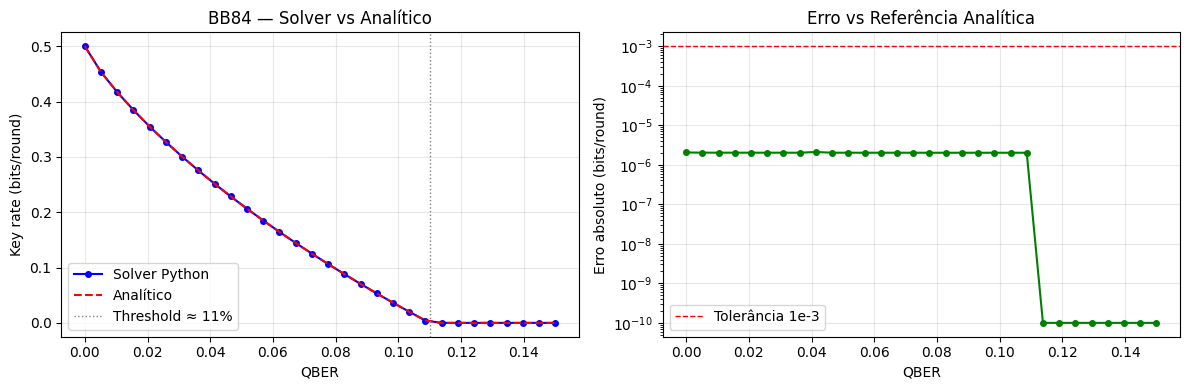

Validação completa da Fase 1 ✅


In [4]:
import sys, numpy as np
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

from openqkd.presets.bb84_preset import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration

def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic(e, pz=0.5):
    s = pz**2 + (1 - pz)**2
    return max(0.0, s * (1 - h(e) - h(e)))

# ── Teste 2: canal perfeito ───────────────────────────────────────────────────
print("=" * 55)
print("TESTE 2 — canal perfeito (QBER=0)")
print("=" * 55)
r0 = MainIteration(BasicBB84Alice2DPreset(error_rate=0.0))
print(f"  Key rate : {r0['key_rate']:.6f}  (esperado ≈ 0.500000)")
assert abs(r0['key_rate'] - 0.5) < 0.001, \
    f"❌ Canal perfeito diverge: {r0['key_rate']:.6f}"
print("  ✅ TESTE 2 passou\n")

# ── Teste 3: acima do threshold ───────────────────────────────────────────────
print("=" * 55)
print("TESTE 3 — acima do threshold (QBER=12%)")
print("=" * 55)
r12 = MainIteration(BasicBB84Alice2DPreset(error_rate=0.12))
print(f"  Key rate : {r12['key_rate']:.6f}  (esperado = 0.000000)")
assert r12['key_rate'] == 0.0, \
    f"❌ Key rate deveria ser zero: {r12['key_rate']:.6f}"
print("  ✅ TESTE 3 passou\n")

# ── Teste 4: pz assimétrico — testa fix do cast complexo ─────────────────────
# ── Teste 4: pz=0.9 — verifica fix do cast complexo ─────────────────────────
print("=" * 55)
print("TESTE 4 — pz=0.9 (verifica fix do cast complexo)")
print("=" * 55)

import warnings

# Captura todos os warnings como texto em vez de tentar importar a classe
with warnings.catch_warnings(record=True) as w_list:
    warnings.simplefilter("always")
    r_asym = MainIteration(BasicBB84Alice2DPreset(error_rate=0.01, pz=0.9))

# Verifica se saiu algum warning de cast complexo
complex_warnings = [str(x.message) for x in w_list if "complex" in str(x.message).lower()]
if complex_warnings:
    print(f"  ❌ ComplexWarning ainda presente:")
    for cw in complex_warnings:
        print(f"     {cw}")
    print("     Verifique se o fix da linha 269 foi salvo corretamente.")
else:
    print("  ✅ Nenhum ComplexWarning detectado")

# Verificação numérica — mais importante que o warning
analytic_asym = bb84_analytic(0.01, pz=0.9)
delta = abs(r_asym['key_rate'] - analytic_asym)
print(f"  Key rate  : {r_asym['key_rate']:.6f}")
print(f"  Analítico : {analytic_asym:.6f}")
print(f"  Δ         : {delta:.2e}  (tolerância: 2e-3)")

assert delta < 0.002, \
    f"❌ pz assimétrico diverge: Δ={delta:.4f} — possível bug no cast complexo"
print("  ✅ TESTE 4 passou\n")



# ── Teste 5: varredura QBER ───────────────────────────────────────────────────
print("=" * 55)
print("TESTE 5 — varredura QBER [0, 0.15]")
print("=" * 55)
import matplotlib.pyplot as plt

error_rates = np.linspace(0, 0.15, 30)
solver_rates, analytic_rates, deltas = [], [], []

for e in error_rates:
    r   = MainIteration(BasicBB84Alice2DPreset(error_rate=float(e)))
    kr  = max(0.0, r["key_rate"])
    an  = bb84_analytic(float(e))
    d   = abs(kr - an)
    solver_rates.append(kr)
    analytic_rates.append(an)
    deltas.append(d)
    print(f"  e={e:.3f} | solver={kr:.5f} | analítico={an:.5f} | Δ={d:.2e}")

max_err = max(deltas)
print(f"\n  Erro máximo: {max_err:.2e}  (tolerância: 1e-3)")
assert max_err < 1e-3, f"❌ Divergência excessiva: {max_err:.4f}"
print("  ✅ TESTE 5 passou\n")

# ── Plot final ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(error_rates, solver_rates,   'b-o', ms=4, label='Solver Python')
ax1.plot(error_rates, analytic_rates, 'r--', lw=1.5, label='Analítico')
ax1.axvline(0.11, color='gray', ls=':', lw=1, label='Threshold ≈ 11%')
ax1.set_xlabel("QBER"); ax1.set_ylabel("Key rate (bits/round)")
ax1.set_title("BB84 — Solver vs Analítico"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.semilogy(error_rates, [max(d, 1e-10) for d in deltas], 'g-o', ms=4)
ax2.axhline(1e-3, color='r', ls='--', lw=1, label='Tolerância 1e-3')
ax2.set_xlabel("QBER"); ax2.set_ylabel("Erro absoluto (bits/round)")
ax2.set_title("Erro vs Referência Analítica"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bb84_validation_completa.png", dpi=150)
plt.show()
print("Validação completa da Fase 1 ✅")


In [2]:
testes = [
    ("QBER=0%,   pz=0.5", 0.00, 0.5),
    ("QBER=1%,   pz=0.5", 0.01, 0.5),
    ("QBER=5%,   pz=0.5", 0.05, 0.5),
    ("QBER=10%,  pz=0.5", 0.10, 0.5),
    ("QBER=12%,  pz=0.5", 0.12, 0.5),
    ("QBER=1%,   pz=0.9", 0.01, 0.9),
    ("QBER=5%,   pz=0.9", 0.05, 0.9),
]

print(f"\n{'Cenário':<22} {'Solver':>10} {'Analítico':>10} {'Δ':>10}  Status")
print("-" * 65)
all_passed = True
for label, e, pz in testes:
    r  = MainIteration(BasicBB84Alice2DPreset(error_rate=e, pz=pz))
    kr = r["key_rate"]
    an = bb84_analytic(e, pz)
    d  = abs(kr - an)
    ok = d < 0.002 and kr <= an + 1e-6
    all_passed = all_passed and ok
    print(f"  {label:<20} {kr:>10.6f} {an:>10.6f} {d:>10.2e}  {'✅' if ok else '❌'}")

print("-" * 65)
print(f"\n{'✅ Fase 2 completa!' if all_passed else '❌ Há falhas'}")



Cenário                    Solver  Analítico          Δ  Status
-----------------------------------------------------------------
  QBER=0%,   pz=0.5      0.499998   0.500000   2.05e-06  ✅
  QBER=1%,   pz=0.5      0.419205   0.419207   2.02e-06  ✅
  QBER=5%,   pz=0.5      0.213601   0.213603   2.02e-06  ✅
  QBER=10%,  pz=0.5      0.031002   0.031004   2.02e-06  ✅
  QBER=12%,  pz=0.5      0.000000   0.000000   0.00e+00  ✅
  QBER=1%,   pz=0.9      0.687497   0.687499   2.03e-06  ✅
  QBER=5%,   pz=0.9      0.350307   0.350309   2.02e-06  ✅
-----------------------------------------------------------------

✅ Fase 2 completa!


TESTE A — optimizer deve encontrar KR >= pz=0.5 fixo
  pz ótimo     : 0.9500  (esperado → 1.0 no regime assintótico)
  KR otimizado : 0.386585
  KR analítico : 0.386587  (para pz=0.9500)
  KR pz=0.5    : 0.213601
  Ganho        : 0.1730  (deve ser > 0)
  ✅ TESTE A passou

TESTE B — varredura QBER com pz otimizado
  e=0.001 | pz*=0.950 | KR_opt=0.88427 | KR_fix=0.48859 | ganho=0.39568
  e=0.010 | pz*=0.950 | KR_opt=0.75870 | KR_fix=0.41920 | ganho=0.33949
  e=0.019 | pz*=0.950 | KR_opt=0.65916 | KR_fix=0.36421 | ganho=0.29495
  e=0.028 | pz*=0.950 | KR_opt=0.57144 | KR_fix=0.31574 | ganho=0.25570
  e=0.037 | pz*=0.950 | KR_opt=0.49162 | KR_fix=0.27163 | ganho=0.21998
  e=0.046 | pz*=0.950 | KR_opt=0.41779 | KR_fix=0.23084 | ganho=0.18695
  e=0.055 | pz*=0.950 | KR_opt=0.34881 | KR_fix=0.19273 | ganho=0.15608
  e=0.064 | pz*=0.950 | KR_opt=0.28392 | KR_fix=0.15688 | ganho=0.12705
  e=0.073 | pz*=0.950 | KR_opt=0.22257 | KR_fix=0.12298 | ganho=0.09959
  e=0.082 | pz*=0.950 | KR_opt=0.1643

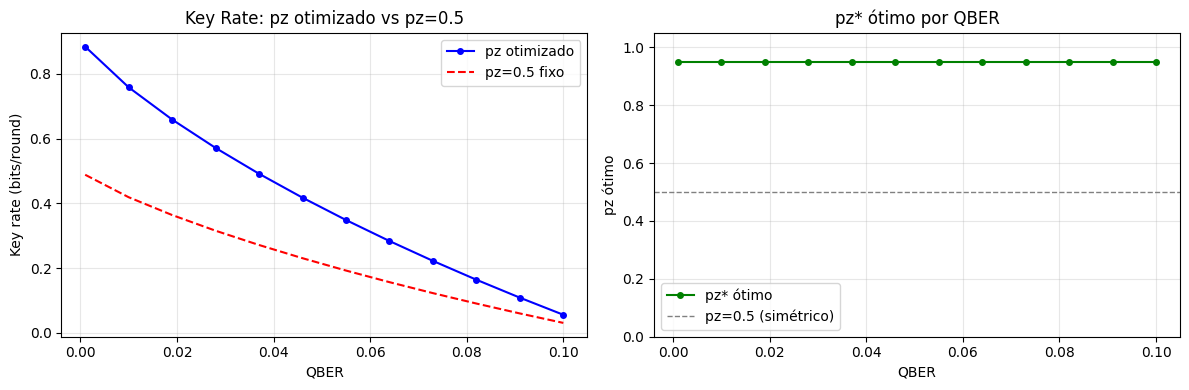


✅ Fase 3 completa!


In [2]:
import sys, numpy as np
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")
from openqkd.presets.bb84_preset import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration

def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic(e, pz=0.5):
    """Fórmula correta para qualquer pz (regime assintótico)."""
    s = pz**2 + (1 - pz)**2
    return max(0.0, s * (1 - 2 * h(e)))

# ── Teste A: optimizer deve ser >= pz fixo ────────────────────────────────────
print("=" * 60)
print("TESTE A — optimizer deve encontrar KR >= pz=0.5 fixo")
print("=" * 60)
r_opt = MainIteration(BasicBB84Alice2DPreset(error_rate=0.05, optimize_pz=True))
r_fix = MainIteration(BasicBB84Alice2DPreset(error_rate=0.05, pz=0.5))

analytic_opt = bb84_analytic(0.05, pz=r_opt['pz'])
print(f"  pz ótimo     : {r_opt['pz']:.4f}  (esperado → 1.0 no regime assintótico)")
print(f"  KR otimizado : {r_opt['key_rate']:.6f}")
print(f"  KR analítico : {analytic_opt:.6f}  (para pz={r_opt['pz']:.4f})")
print(f"  KR pz=0.5    : {r_fix['key_rate']:.6f}")
print(f"  Ganho        : {r_opt['key_rate'] - r_fix['key_rate']:.4f}  (deve ser > 0)")

assert 0.0 < r_opt['pz'] <= 1.0,          "❌ pz fora do intervalo válido"
assert r_opt['key_rate'] >= r_fix['key_rate'] - 1e-5, \
    "❌ optimizer retornou KR pior que pz=0.5!"
assert abs(r_opt['key_rate'] - analytic_opt) < 0.002, \
    f"❌ KR otimizado diverge do analítico: Δ={abs(r_opt['key_rate']-analytic_opt):.4f}"
print("  ✅ TESTE A passou\n")

# ── Teste B: varredura QBER com otimização ────────────────────────────────────
print("=" * 60)
print("TESTE B — varredura QBER com pz otimizado")
print("=" * 60)
import matplotlib.pyplot as plt

error_rates  = np.linspace(0.001, 0.10, 12)
kr_optimized, kr_fixed, pz_vals = [], [], []

for e in error_rates:
    r_o = MainIteration(BasicBB84Alice2DPreset(error_rate=float(e), optimize_pz=True))
    r_f = MainIteration(BasicBB84Alice2DPreset(error_rate=float(e), pz=0.5))
    kr_optimized.append(r_o["key_rate"])
    kr_fixed.append(r_f["key_rate"])
    pz_vals.append(r_o["pz"])
    ganho = r_o["key_rate"] - r_f["key_rate"]
    print(f"  e={e:.3f} | pz*={r_o['pz']:.3f} | "
          f"KR_opt={r_o['key_rate']:.5f} | KR_fix={r_f['key_rate']:.5f} | "
          f"ganho={ganho:.5f}")
    assert r_o["key_rate"] >= r_f["key_rate"] - 1e-5, \
        f"❌ e={e:.3f}: optimizer pior que pz=0.5"

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(error_rates, kr_optimized, 'b-o', ms=4, label='pz otimizado')
ax1.plot(error_rates, kr_fixed,     'r--', ms=4, label='pz=0.5 fixo')
ax1.set_xlabel("QBER"); ax1.set_ylabel("Key rate (bits/round)")
ax1.set_title("Key Rate: pz otimizado vs pz=0.5")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(error_rates, pz_vals, 'g-o', ms=4, label='pz* ótimo')
ax2.axhline(0.5, color='gray', ls='--', lw=1, label='pz=0.5 (simétrico)')
ax2.set_ylim(0, 1.05)
ax2.set_xlabel("QBER"); ax2.set_ylabel("pz ótimo")
ax2.set_title("pz* ótimo por QBER"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bb84_optimizer.png", dpi=150)
plt.show()
print("\n✅ Fase 3 completa!")



  QBER |   Upper bd |   Lower bd |    Leak EC |   Dual gap |     Solver |  Analítico |        Δ
------------------------------------------------------------------------------------------
  0.00  |   0.500000 |   0.499998 |   0.000000 |   2.05e-06 |   0.499998 |   0.500000 | 2.05e-06
  0.01  |   0.459603 |   0.459601 |   0.040397 |   2.02e-06 |   0.419205 |   0.419207 | 2.02e-06
  0.02  |   0.429280 |   0.429278 |   0.070720 |   2.02e-06 |   0.358557 |   0.358559 | 2.02e-06
  0.03  |   0.402804 |   0.402802 |   0.097196 |   2.02e-06 |   0.305606 |   0.305608 | 2.02e-06
  0.04  |   0.378854 |   0.378852 |   0.121146 |   2.02e-06 |   0.257706 |   0.257708 | 2.02e-06
  0.05  |   0.356802 |   0.356800 |   0.143198 |   2.02e-06 |   0.213601 |   0.213603 | 2.02e-06
  0.06  |   0.336278 |   0.336276 |   0.163722 |   2.01e-06 |   0.172553 |   0.172555 | 2.02e-06
  0.07  |   0.317038 |   0.317036 |   0.182962 |   2.02e-06 |   0.134074 |   0.134076 | 2.02e-06
  0.08  |   0.298910 |   0.298908 | 

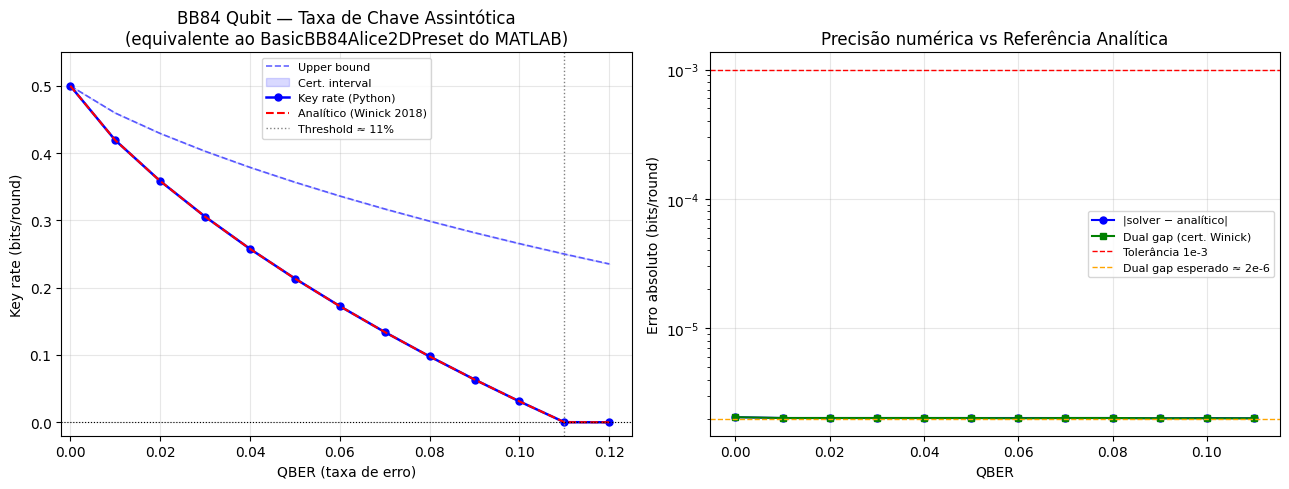

  → bb84_benchmark.png salvo


In [3]:
import sys, numpy as np
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")
from openqkd.presets.bb84_preset   import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration
import matplotlib.pyplot as plt
import csv

# ── Fórmula analítica de referência (Winick et al. 2018, Eq. 1) ──────────────
def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic(e, pz=0.5):
    s = pz**2 + (1 - pz)**2
    return max(0.0, s * (1 - 2 * h(e)))

# ── Pontos de comparação — mesmos do MATLAB BasicBB84Alice2DPreset ────────────
# Ref: openQKDsecurity/Tutorials/BasicBB84Alice2D (error_rates = 0:0.01:0.12)
error_rates = np.arange(0.00, 0.125, 0.01)

rows = []
print(f"\n{'QBER':>6} | {'Upper bd':>10} | {'Lower bd':>10} | {'Leak EC':>10} | "
      f"{'Dual gap':>10} | {'Solver':>10} | {'Analítico':>10} | {'Δ':>8}")
print("-" * 90)

for e in error_rates:
    r  = MainIteration(BasicBB84Alice2DPreset(error_rate=float(e), pz=0.5))
    an = bb84_analytic(float(e), pz=0.5)
    d  = abs(r["key_rate"] - an)
    dg = r["upper_bound"] - r["lower_bound"]
    rows.append({
        "qber":        round(float(e), 4),
        "upper_bound": round(r["upper_bound"],  8),
        "lower_bound": round(r["lower_bound"],  8),
        "leak_ec":     round(r["leak_ec"],      8),
        "dual_gap":    round(dg,                8),  # ← era 2e-8, deve ser 8
        "key_rate":    round(r["key_rate"],     8),
        "analytic":    round(an,                8),
        "delta":       round(d,                 8),  # ← era 2e-8, deve ser 8
    })

    print(f"  {e:.2f}  | {r['upper_bound']:>10.6f} | {r['lower_bound']:>10.6f} | "
          f"{r['leak_ec']:>10.6f} | {dg:>10.2e} | "
          f"{r['key_rate']:>10.6f} | {an:>10.6f} | {d:>8.2e}")

# ── Exporta CSV para comparar com MATLAB ─────────────────────────────────────
with open("bb84_benchmark.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print("\n  → bb84_benchmark.csv salvo (compare com MATLAB)")

# ── Plot equivalente ao QKDPlot do MATLAB ────────────────────────────────────
kr_solver   = [r["key_rate"]    for r in rows]
kr_analytic = [r["analytic"]    for r in rows]
upper_bd    = [r["upper_bound"] for r in rows]
lower_bd    = [r["lower_bound"] for r in rows]
er          = [r["qber"]        for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Gráfico 1: Key rate ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(er, upper_bd,    'b--', lw=1.2, alpha=0.6, label='Upper bound')
ax.fill_between(er, lower_bd, upper_bd, alpha=0.15, color='blue', label='Cert. interval')
ax.plot(er, kr_solver,   'b-o', ms=5,  lw=1.8,     label='Key rate (Python)')
ax.plot(er, kr_analytic, 'r--', lw=1.5,            label='Analítico (Winick 2018)')
ax.axhline(0, color='k', ls=':', lw=0.8)
ax.axvline(0.11, color='gray', ls=':', lw=1, label='Threshold ≈ 11%')
ax.set_xlabel("QBER (taxa de erro)")
ax.set_ylabel("Key rate (bits/round)")
ax.set_title("BB84 Qubit — Taxa de Chave Assintótica\n(equivalente ao BasicBB84Alice2DPreset do MATLAB)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlim(-0.002, 0.125); ax.set_ylim(-0.02, 0.55)

# ── Gráfico 2: Erro vs analítico ─────────────────────────────────────────────
ax2 = axes[1]
deltas    = [r["delta"]    for r in rows if r["analytic"] > 0]
dual_gaps = [r["dual_gap"] for r in rows if r["analytic"] > 0]
er_pos    = [r["qber"]     for r in rows if r["analytic"] > 0]
ax2.semilogy(er_pos, deltas,    'b-o', ms=5, label='|solver − analítico|')
ax2.semilogy(er_pos, dual_gaps, 'g-s', ms=5, label='Dual gap (cert. Winick)')
ax2.axhline(1e-3, color='r', ls='--', lw=1, label='Tolerância 1e-3')
ax2.axhline(2e-6, color='orange', ls='--', lw=1, label='Dual gap esperado ≈ 2e-6')
ax2.set_xlabel("QBER"); ax2.set_ylabel("Erro absoluto (bits/round)")
ax2.set_title("Precisão numérica vs Referência Analítica")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bb84_benchmark.png", dpi=150)
plt.show()
print("  → bb84_benchmark.png salvo")


Rodando Python com os mesmos pontos do MATLAB...

    e |  f(ρ*) MATLAB |  f(ρ*) Python |     Δf(ρ*) |  KR MATLAB |  KR Python |        ΔKR
------------------------------------------------------------------------------------------
  0.00 |      0.500000 |      0.500000 |   0.000000 |   0.500000 |   0.499998 |   0.000002
  0.01 |      0.456324 |      0.459603 |  -0.003279 |   0.412648 |   0.419205 |  -0.006557
  0.02 |      0.423736 |      0.429280 |  -0.005544 |   0.347473 |   0.358557 |  -0.011084
  0.03 |      0.395390 |      0.402804 |  -0.007414 |   0.290780 |   0.305606 |  -0.014826
  0.04 |      0.369830 |      0.378854 |  -0.009024 |   0.239659 |   0.257706 |  -0.018047
  0.05 |      0.346366 |      0.356802 |  -0.010436 |   0.192732 |   0.213601 |  -0.020869 ←
  0.06 |      0.324592 |      0.336278 |  -0.011686 |   0.149184 |   0.172553 |  -0.023369 ←
  0.07 |      0.304240 |      0.317038 |  -0.012798 |   0.108481 |   0.134074 |  -0.025593 ←
  0.08 |      0.285121 |      0.298

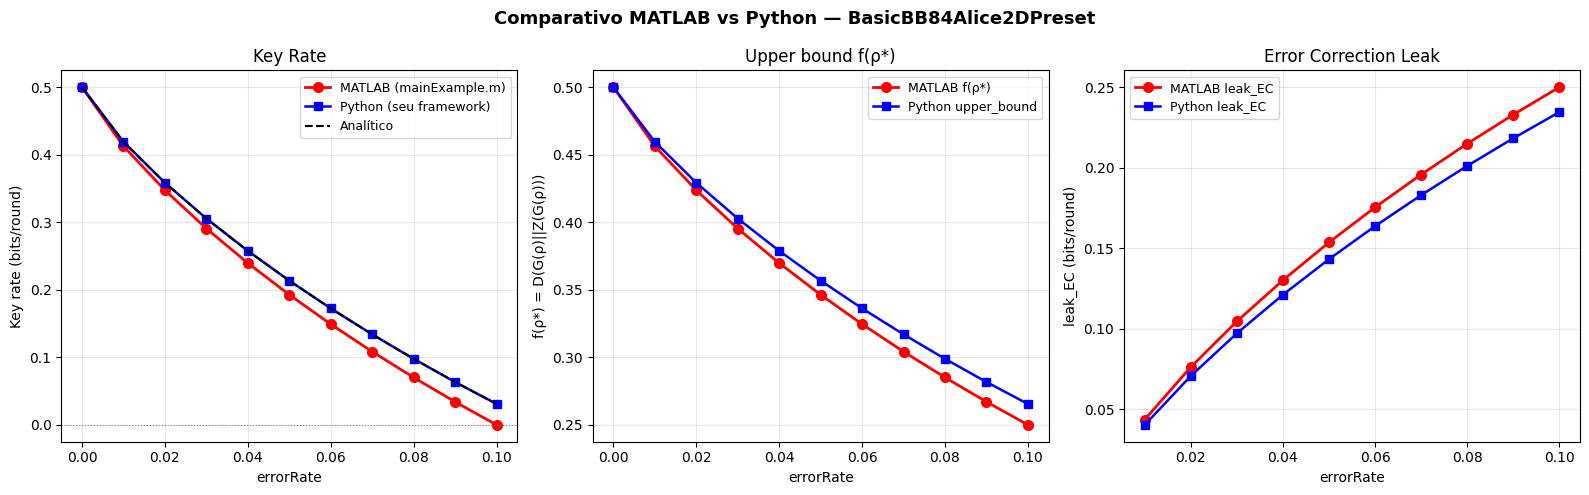

In [1]:
import sys, numpy as np
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")
from openqkd.presets.bb84_preset      import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration
import matplotlib.pyplot as plt, csv

# ── Resultados extraídos do output do MATLAB ──────────────────────────────────
# Fonte: mainExample.m, BasicBB84Alice2DPreset, 11 pontos e=0:0.01:0.10
matlab_data = [
    {"e": 0.00, "func_val": 0.500000, "key_rate": 0.500000},
    {"e": 0.01, "func_val": 0.456324, "key_rate": 0.412648},
    {"e": 0.02, "func_val": 0.423736, "key_rate": 0.347473},
    {"e": 0.03, "func_val": 0.395390, "key_rate": 0.290780},
    {"e": 0.04, "func_val": 0.369830, "key_rate": 0.239659},
    {"e": 0.05, "func_val": 0.346366, "key_rate": 0.192732},
    {"e": 0.06, "func_val": 0.324592, "key_rate": 0.149184},
    {"e": 0.07, "func_val": 0.304240, "key_rate": 0.108481},
    {"e": 0.08, "func_val": 0.285121, "key_rate": 0.070241},
    {"e": 0.09, "func_val": 0.267091, "key_rate": 0.034182},
    {"e": 0.10, "func_val": 0.250042, "key_rate": 0.000084},
]

# ── Referência analítica ──────────────────────────────────────────────────────
def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic(e, pz=0.5):
    return max(0.0, (pz**2 + (1-pz)**2) * (1 - 2*h(e)))

# ── Roda Python com os mesmos 11 pontos do MATLAB ────────────────────────────
print("Rodando Python com os mesmos pontos do MATLAB...")
rows = []
for m in matlab_data:
    e  = m["e"]
    r  = MainIteration(BasicBB84Alice2DPreset(error_rate=e, pz=0.5))
    an = bb84_analytic(e)
    rows.append({
        "e":              e,
        "matlab_funcval": m["func_val"],
        "python_ub":      r["upper_bound"],
        "delta_funcval":  m["func_val"] - r["upper_bound"],
        "matlab_kr":      m["key_rate"],
        "python_kr":      r["key_rate"],
        "analytic_kr":    an,
        "delta_kr":       m["key_rate"] - r["key_rate"],
        "python_leakec":  r["leak_ec"],
        "matlab_leakec":  m["func_val"] - m["key_rate"],
    })

# ── Tabela comparativa ────────────────────────────────────────────────────────
print(f"\n{'e':>5} | {'f(ρ*) MATLAB':>13} | {'f(ρ*) Python':>13} | "
      f"{'Δf(ρ*)':>10} | {'KR MATLAB':>10} | {'KR Python':>10} | {'ΔKR':>10}")
print("-" * 90)
for r in rows:
    flag = " ←" if abs(r["delta_funcval"]) > 0.01 else ""
    print(f"  {r['e']:.2f} | {r['matlab_funcval']:>13.6f} | {r['python_ub']:>13.6f} | "
          f"{r['delta_funcval']:>10.6f} | {r['matlab_kr']:>10.6f} | "
          f"{r['python_kr']:>10.6f} | {r['delta_kr']:>10.6f}{flag}")

# ── Diagnóstico do leak_ec ────────────────────────────────────────────────────
print(f"\n{'e':>5} | {'leakEC MATLAB':>14} | {'leakEC Python':>14} | {'Δ leak':>10}")
print("-" * 52)
for r in rows:
    if r["e"] > 0:
        print(f"  {r['e']:.2f} | {r['matlab_leakec']:>14.6f} | {r['python_leakec']:>14.6f} | "
              f"{r['matlab_leakec']-r['python_leakec']:>10.6f}")

# ── Export CSV ────────────────────────────────────────────────────────────────
with open("comparison_matlab_python.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader(); writer.writerows(rows)
print("\n→ comparison_matlab_python.csv exportado")

# ── Plot ──────────────────────────────────────────────────────────────────────
er  = [r["e"]            for r in rows]
km  = [r["matlab_kr"]    for r in rows]
kp  = [r["python_kr"]    for r in rows]
ka  = [r["analytic_kr"]  for r in rows]
fm  = [r["matlab_funcval"] for r in rows]
fp  = [r["python_ub"]    for r in rows]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparativo MATLAB vs Python — BasicBB84Alice2DPreset", fontsize=13, fontweight='bold')

# Painel 1: Key rates
ax1 = axes[0]
ax1.plot(er, km, 'r-o', ms=7, lw=2,   label='MATLAB (mainExample.m)')
ax1.plot(er, kp, 'b-s', ms=6, lw=1.8, label='Python (seu framework)')
ax1.plot(er, ka, 'k--', lw=1.5,       label='Analítico')
ax1.axhline(0, color='gray', ls=':', lw=0.8)
ax1.set_xlabel("errorRate"); ax1.set_ylabel("Key rate (bits/round)")
ax1.set_title("Key Rate"); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Painel 2: f(ρ*) = upper bound
ax2 = axes[1]
ax2.plot(er, fm, 'r-o', ms=7, lw=2,   label='MATLAB f(ρ*)')
ax2.plot(er, fp, 'b-s', ms=6, lw=1.8, label='Python upper_bound')
ax2.set_xlabel("errorRate"); ax2.set_ylabel("f(ρ*) = D(G(ρ)||Z(G(ρ)))")
ax2.set_title("Upper bound f(ρ*)"); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# Painel 3: leak_ec
ax3 = axes[2]
lm = [r["matlab_leakec"] for r in rows if r["e"] > 0]
lp = [r["python_leakec"] for r in rows if r["e"] > 0]
ep = [r["e"]             for r in rows if r["e"] > 0]
ax3.plot(ep, lm, 'r-o', ms=7, lw=2,   label='MATLAB leak_EC')
ax3.plot(ep, lp, 'b-s', ms=6, lw=1.8, label='Python leak_EC')
ax3.set_xlabel("errorRate"); ax3.set_ylabel("leak_EC (bits/round)")
ax3.set_title("Error Correction Leak"); ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_matlab_python.png", dpi=150)
plt.show()


── Modo Theory: key rate vs QBER ──

── Modo Matlab: key rate vs depolarization ──
 depol |     MATLAB |     Python |          Δ
----------------------------------------------
  0.000 |   0.500000 |   0.499998 |   2.05e-06
  0.022 |   0.412648 |   0.412646 |   1.94e-06
  0.044 |   0.347473 |   0.347471 |   2.35e-06
  0.066 |   0.290780 |   0.290778 |   2.50e-06
  0.088 |   0.239659 |   0.239657 |   1.64e-06
  0.110 |   0.192732 |   0.192730 |   2.38e-06
  0.132 |   0.149184 |   0.149182 |   1.95e-06
  0.154 |   0.108481 |   0.108479 |   2.28e-06
  0.176 |   0.070241 |   0.070239 |   1.63e-06
  0.198 |   0.034182 |   0.034180 |   1.64e-06
  0.220 |   0.000084 |   0.000082 |   1.97e-06


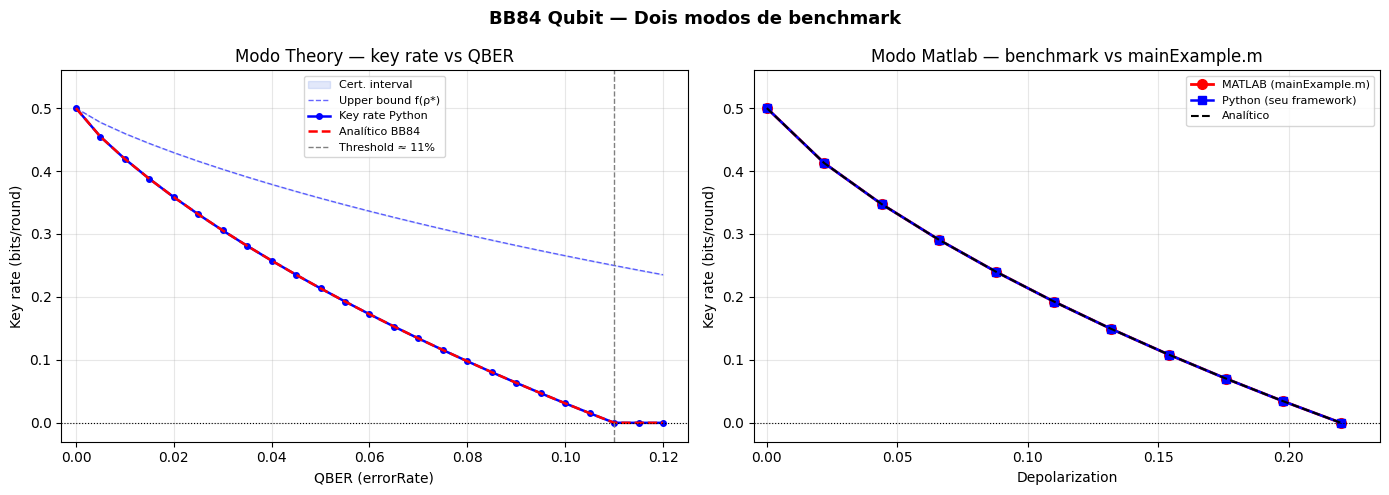


→ bb84_theory.csv e bb84_matlab_benchmark.csv exportados
→ Erro máximo Python vs MATLAB: 2.50e-06 bits/round
→ ✅ Benchmark aprovado (Δ < 1e-2)


In [1]:
import sys, numpy as np
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")
from openqkd.presets.bb84_preset      import BasicBB84Alice2DPreset
from openqkd.optimizer.main_iteration import MainIteration
import matplotlib.pyplot as plt, csv

def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic(qber, pz=0.5):
    s = pz**2 + (1 - pz)**2
    return max(0.0, s * (1 - 2 * h(qber)))

# ════════════════════════════════════════════════════════════════════════
# CURVA 1 — modo theory: key rate vs QBER (comparação analítica)
# ════════════════════════════════════════════════════════════════════════
qber_range = np.linspace(0, 0.12, 25)
rows_theory = []
print("── Modo Theory: key rate vs QBER ──")
for qber in qber_range:
    r  = MainIteration(BasicBB84Alice2DPreset(error_rate=float(qber), pz=0.5))
    an = bb84_analytic(float(qber))
    rows_theory.append({
        "qber":       round(float(qber), 6),
        "key_rate":   round(r["key_rate"],    8),
        "upper_bound":round(r["upper_bound"], 8),
        "lower_bound":round(r["lower_bound"], 8),
        "leak_ec":    round(r["leak_ec"],     8),
        "analytic":   round(an,               8),
        "delta":      round(abs(r["key_rate"] - an), 8),
    })

with open("bb84_theory.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=rows_theory[0].keys())
    w.writeheader(); w.writerows(rows_theory)

# ════════════════════════════════════════════════════════════════════════
# CURVA 2 — modo matlab: key rate vs depolarization (benchmark MATLAB)
# ════════════════════════════════════════════════════════════════════════
# Mesmos 11 pontos do mainExample.m: linspace(0, 0.22, 11)
depol_range = np.linspace(0, 0.22, 11)

# Resultados do MATLAB (extraídos do seu output anterior)
matlab_kr = [0.500000, 0.412648, 0.347473, 0.290780, 0.239659,
             0.192732, 0.149184, 0.108481, 0.070241, 0.034182, 0.000084]

rows_matlab = []
print("\n── Modo Matlab: key rate vs depolarization ──")
print(f"{'depol':>6} | {'MATLAB':>10} | {'Python':>10} | {'Δ':>10}")
print("-" * 46)
for d, km in zip(depol_range, matlab_kr):
    r = MainIteration(BasicBB84Alice2DPreset(depolarization=float(d), pz=0.5))
    delta = abs(r["key_rate"] - km)
    rows_matlab.append({
        "depolarization": round(float(d), 6),
        "qber":           round(float(d) / 2, 6),
        "matlab_kr":      round(km,            8),
        "python_kr":      round(r["key_rate"], 8),
        "delta":          round(delta,         8),
        "upper_bound":    round(r["upper_bound"], 8),
        "lower_bound":    round(r["lower_bound"], 8),
    })
    print(f"  {d:.3f} | {km:>10.6f} | {r['key_rate']:>10.6f} | {delta:>10.2e}")

with open("bb84_matlab_benchmark.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=rows_matlab[0].keys())
    w.writeheader(); w.writerows(rows_matlab)

# ════════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("BB84 Qubit — Dois modos de benchmark", fontsize=13, fontweight="bold")

# ── Painel 1: theory ─────────────────────────────────────────────────────
ax1 = axes[0]
er = [r["qber"]       for r in rows_theory]
kp = [r["key_rate"]   for r in rows_theory]
ub = [r["upper_bound"]for r in rows_theory]
lb = [r["lower_bound"]for r in rows_theory]
an = [r["analytic"]   for r in rows_theory]

ax1.fill_between(er, lb, ub, alpha=0.15, color="royalblue", label="Cert. interval")
ax1.plot(er, ub, "b--", lw=1,   alpha=0.6, label="Upper bound f(ρ*)")
ax1.plot(er, kp, "b-o", ms=4,   lw=1.8,    label="Key rate Python")
ax1.plot(er, an, "r--", lw=1.8,            label="Analítico BB84")
ax1.axhline(0,    color="k",    ls=":", lw=0.8)
ax1.axvline(0.11, color="gray", ls="--", lw=1, label="Threshold ≈ 11%")
ax1.set_xlabel("QBER (errorRate)");  ax1.set_ylabel("Key rate (bits/round)")
ax1.set_title("Modo Theory — key rate vs QBER")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_xlim(-0.003, 0.125); ax1.set_ylim(-0.03, 0.56)

# ── Painel 2: matlab benchmark ───────────────────────────────────────────
ax2 = axes[1]
dp  = [r["depolarization"] for r in rows_matlab]
km_ = [r["matlab_kr"]      for r in rows_matlab]
kp_ = [r["python_kr"]      for r in rows_matlab]
an_ = [bb84_analytic(r["qber"]) for r in rows_matlab]

ax2.plot(dp, km_, "r-o", ms=7,  lw=2,   label="MATLAB (mainExample.m)")
ax2.plot(dp, kp_, "b-s", ms=6,  lw=1.8, label="Python (seu framework)")
ax2.plot(dp, an_, "k--", lw=1.5,        label="Analítico")
ax2.axhline(0, color="k", ls=":", lw=0.8)
ax2.set_xlabel("Depolarization"); ax2.set_ylabel("Key rate (bits/round)")
ax2.set_title("Modo Matlab — benchmark vs mainExample.m")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
ax2.set_xlim(-0.005, 0.235); ax2.set_ylim(-0.03, 0.56)

plt.tight_layout()
plt.savefig("bb84_dual_benchmark.png", dpi=150)
plt.show()

max_d = max(r["delta"] for r in rows_matlab)
print(f"\n→ bb84_theory.csv e bb84_matlab_benchmark.csv exportados")
print(f"→ Erro máximo Python vs MATLAB: {max_d:.2e} bits/round")
print(f"→ {'✅ Benchmark aprovado (Δ < 1e-2)' if max_d < 0.01 else '⚠️  Diferença acima de 1e-2 — investigar'}")
